In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Step 1 - Loading SPY and daily returns

In [14]:
# Load your 3 WSJ CSV files from data folder
# Replace 'SPY.csv', 'QQQ.csv', 'IWM.csv' with your ACTUAL filenames
spy_data = pd.read_csv('/Users/Sinthu/Desktop/(Quant Trading Project)/data/spy.csv', parse_dates=['Date'], date_format='%m/%d/%y', index_col='Date')
qqq_data = pd.read_csv('/Users/Sinthu/Desktop/(Quant Trading Project)/data/qqq.csv', parse_dates=['Date'], date_format='%m/%d/%y', index_col='Date')
iwm_data = pd.read_csv('/Users/Sinthu/Desktop/(Quant Trading Project)/data/iwm.csv', parse_dates=['Date'], date_format='%m/%d/%y', index_col='Date')

#Clean up column names for each data set (they have unneccasary space at the beginning of the column
spy_data.columns = spy_data.columns.str.strip()
qqq_data.columns = qqq_data.columns.str.strip()
iwm_data.columns = iwm_data.columns.str.strip()

#Making sure dates start with oldest to newest
spy_data.sort_index(inplace=True)
qqq_data.sort_index(inplace=True)
iwm_data.sort_index(inplace=True)

In [3]:
# Extract adjusted close prices and combine
spy = pd.DataFrame({'Adj_Close': spy_data['Close']  })

print("Combined prices shape:", spy.shape)
print("\nFirst 5 rows:")
spy.head()

Combined prices shape: (8341, 1)

First 5 rows:


,Adj_Close
Date,
1993-01-29,43.9375
1993-02-01,44.2500
1993-02-02,44.3438
1993-02-03,44.8125
1993-02-04,45.0000


In [4]:
spy["log_return"] = np.log(spy["Adj_Close"] / spy["Adj_Close"].shift(1))
spy = spy.dropna(subset=["log_return"])
spy.head()

,Adj_Close,log_return
Date,,
1993-02-01,44.2500,0.007087
1993-02-02,44.3438,0.002118
1993-02-03,44.8125,0.010514
1993-02-04,45.0000,0.004175
1993-02-05,44.9688,-0.000694


Step 2 - Compute 50 day and 200 day moving averages

In [5]:
#Moving Averages
short_window = 50
long_window = 200

spy["ma_short"] = spy["Adj_Close"].rolling(window=short_window).mean()
spy["ma_long"] = spy["Adj_Close"].rolling(window=long_window).mean()

spy[["Adj_Close", "ma_short", "ma_long"]].head(220)

,Adj_Close,ma_short,ma_long
Date,,,
1993-02-01,44.2500,NaN,NaN
1993-02-02,44.3438,NaN,NaN
1993-02-03,44.8125,NaN,NaN
1993-02-04,45.0000,NaN,NaN
1993-02-05,44.9688,NaN,NaN
...,...,...,...
1993-12-07,46.8438,46.429404,45.396589
1993-12-08,46.8438,46.442530,45.409557
1993-12-09,46.6875,46.455654,45.421276


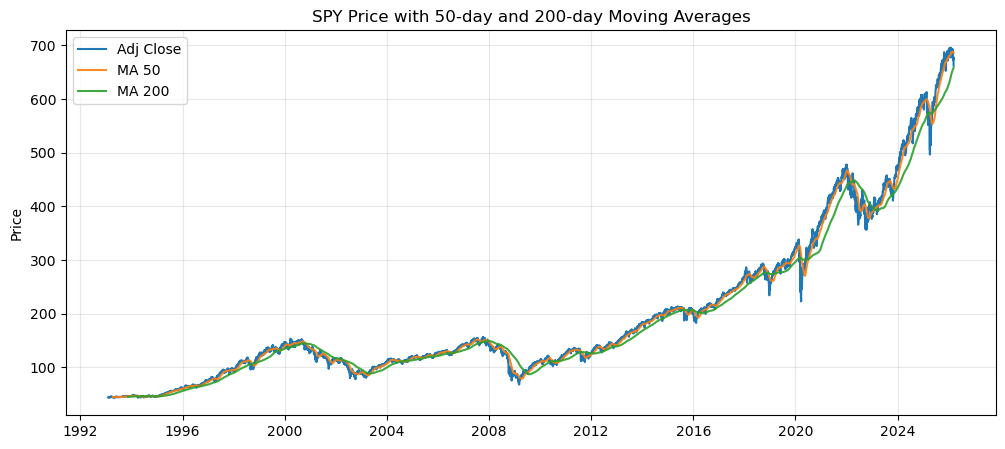

In [6]:
#Plot Close Price and Moving averages
plt.figure(figsize=(12, 5))
plt.plot(spy.index, spy["Adj_Close"], label="Adj Close", linewidth=1.5)
plt.plot(spy.index, spy["ma_short"], label=f"MA {short_window}", alpha=0.9)
plt.plot(spy.index, spy["ma_long"], label=f"MA {long_window}", alpha=0.9)
plt.title("SPY Price with 50-day and 200-day Moving Averages")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Step 3 - Create daily signals (1 = long, 0 = flat)

- Signal = 1 when short MA > long MA (uptrend)
- Signal = 0 otherwise

A daily signal simply is a rule that tells you what to do on each day.
 - 1 is being invested (buy/ hold)
 - 0 is stay out (cash)
 - ma short > ma long - means recent prices are higher than long term average. Market is in an uptrend and the Momentum is positive.

Moving Average Crossover Strategy
- Golden Cross: short MA crosses above long MA -> bullish
- Death Cross: short MA crosses above long MA -> bearish

This is a raw idea, not yet realistic - assuming you can act instantly. It's not accounting for execution delay, transcation costs and look-ahead bias.

In proper backtesting you would alter the code, so "you only act after the signal is observed".

In [7]:
#Raw (contemporaneous) signal
spy["signal_raw"] = 0
spy.loc[spy["ma_short"] > spy["ma_long"], "signal_raw"] = 1

spy[["Adj_Close", "ma_short", "ma_long", "signal_raw"]].tail(220)

,Adj_Close,ma_short,ma_long,signal_raw
Date,,,,
2025-04-29,554.32,559.8046,573.07140,0
2025-04-30,554.54,558.6656,573.04415,0
2025-05-01,558.47,557.5764,573.02885,0
2025-05-02,566.76,556.7040,573.03835,0
2025-05-05,563.51,555.9754,573.07120,0
...,...,...,...,...
2026-03-09,678.27,687.8562,656.86775,1
2026-03-10,677.18,687.5922,657.33935,1
2026-03-11,676.33,687.3126,657.80555,1


- Head is the first few lines of data from the start (newest)
- Tail is the last few lines of data from the end (oldest)

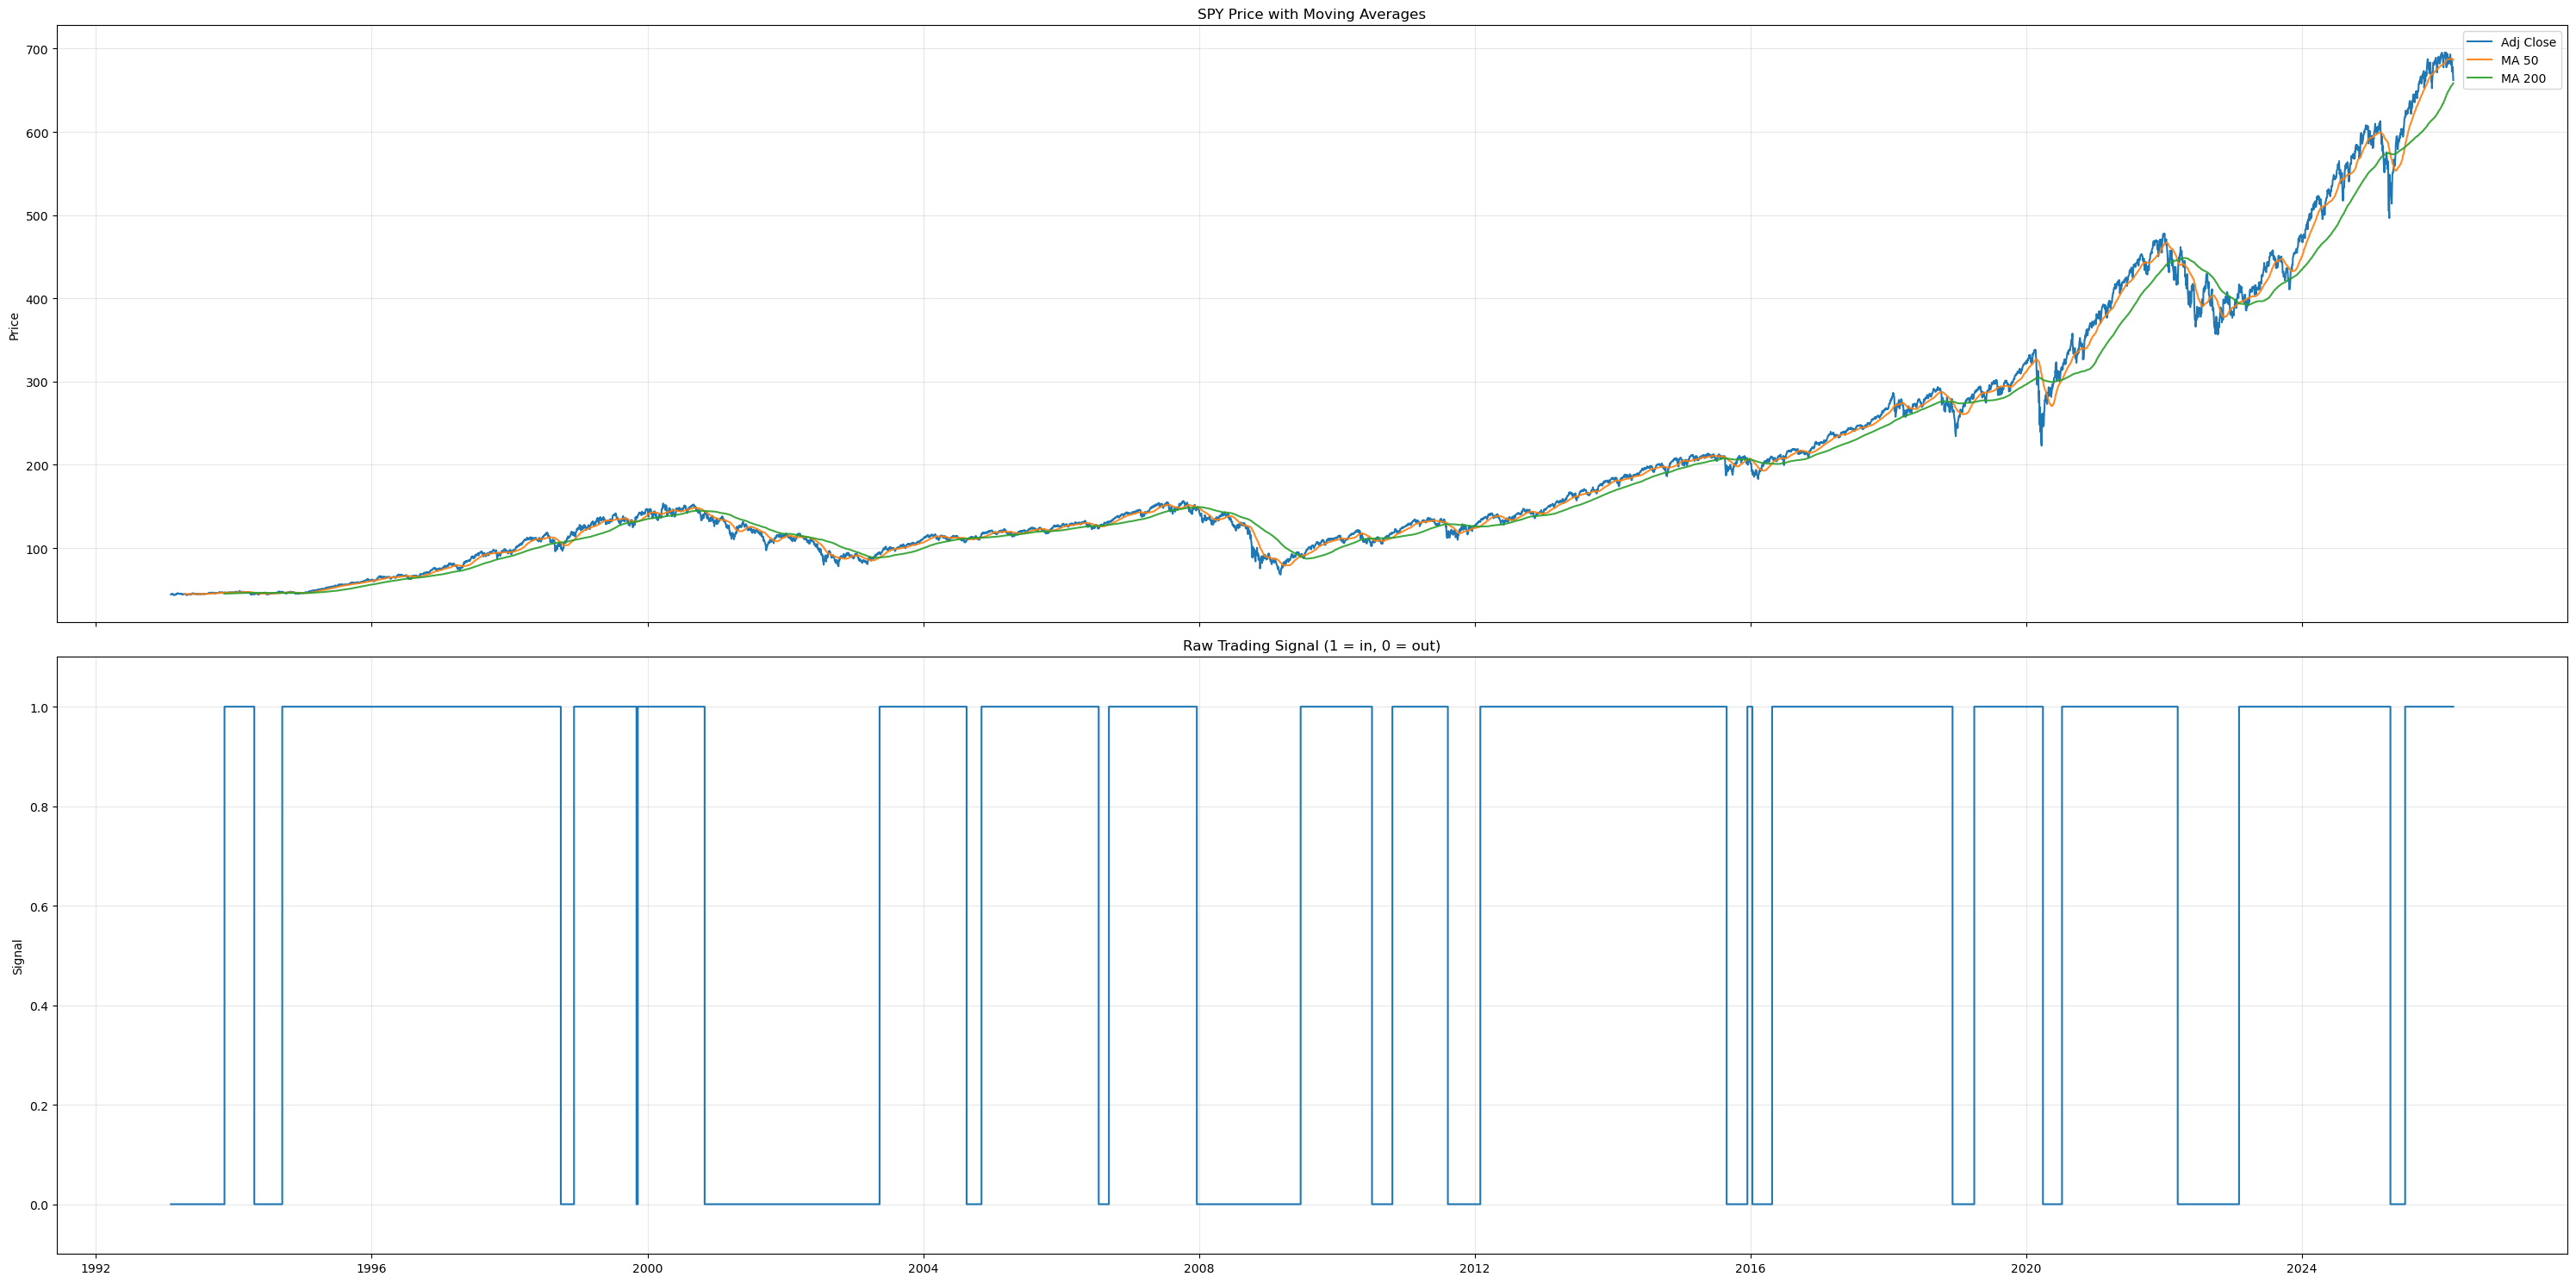

In [8]:
#Visualising signal as a separate panel
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(30, 15), sharex=True)

# Price and MAs
ax1.plot(spy.index, spy["Adj_Close"], label="Adj Close", linewidth=1.5)
ax1.plot(spy.index, spy["ma_short"], label=f"MA {short_window}", alpha=0.9)
ax1.plot(spy.index, spy["ma_long"], label=f"MA {long_window}", alpha=0.9)
ax1.set_title("SPY Price with Moving Averages")
ax1.set_ylabel("Price")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Signal
ax2.plot(spy.index, spy["signal_raw"], label="Signal (raw)", drawstyle="steps-post")
ax2.set_title("Raw Trading Signal (1 = in, 0 = out)")
ax2.set_ylabel("Signal")
ax2.set_ylim(-0.1, 1.1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Step 4 - Prepare a "backtest-ready" signal (no look ahead)

- To avoid look ahead bias, we will use yesterday's signal to decide today's position
- Using the market momentum and trend from the previous day to predict the signal action for the next day

In [9]:
spy["signal"] = spy["signal_raw"].shift(1)
spy = spy.dropna(subset=["signal"])

spy[["Adj_Close", "ma_short", "ma_long", "signal_raw", "signal"]].head(10)

,Adj_Close,ma_short,ma_long,signal_raw,signal
Date,,,,,
1993-02-02,44.3438,NaN,NaN,0,0.0
1993-02-03,44.8125,NaN,NaN,0,0.0
1993-02-04,45.0000,NaN,NaN,0,0.0
1993-02-05,44.9688,NaN,NaN,0,0.0
1993-02-08,44.9688,NaN,NaN,0,0.0
1993-02-09,44.6563,NaN,NaN,0,0.0
1993-02-10,44.7188,NaN,NaN,0,0.0
1993-02-11,44.9375,NaN,NaN,0,0.0
1993-02-12,44.5938,NaN,NaN,0,0.0


In [10]:
spy = spy.sort_index()

In [11]:
#Checking a few points arounda a crossover
#Picking a date range where the MAs cross over and inspect
start = "2018-05-01"
end = "2018-06-30"

spy.loc[start:end, ["Adj_Close", "ma_short", "ma_long", "signal_raw", "signal"]].head(120)

,Adj_Close,ma_short,ma_long,signal_raw,signal
Date,,,,,
2018-05-01,264.98,268.1452,261.02080,1,1.0
2018-05-02,263.20,267.9812,261.10915,1,1.0
2018-05-03,262.62,267.8326,261.19395,1,1.0
2018-05-04,266.02,267.7450,261.28910,1,1.0
2018-05-07,266.92,267.5892,261.38820,1,1.0
2018-05-08,266.92,267.3696,261.48840,1,1.0
2018-05-09,269.50,267.2710,261.60180,1,1.0
2018-05-10,272.02,267.2784,261.72480,1,1.0
2018-05-11,272.85,267.3814,261.85190,1,1.0


Step 5 - Simple signal stats

In [12]:
#Time spent in the market
fraction_in_market = spy["signal"].mean()
print(f"Fraction of days with position = 1: {fraction_in_market:.2%}")

Fraction of days with position = 1: 73.28%


In [13]:
#Count switches
switches = spy["signal"].diff().abs().sum()
print(f"Approximate number of signal changes (0↔1): {switches:.0f}")

Approximate number of signal changes (0↔1): 31


## Moving-average signals – reflections

- What I understand about the signal rule (MA 50 > MA 200):
  - Trying to notice when short MA will beat long MA, showing good time to invest to holding out

- Why I need to shift the signal by one day for backtesting:
  - As we don't know actual closing price for the current day being in the future, we see the momentmum for the previous day to signal what we should invest today.

- Approx. fraction of days the strategy is in the market:
  - 73.28 %

- Anything surprising about how often the signal flips:
  - Fairly low number of days for a large dataset, showing not huge investment moments

- Anything confusing or unclear about the MA signal construction:
  - How to determine what is the right number of short MA days and long MA days?
    -Does this vary with different assets or how is this calculated?
    
